In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.5 MB/s eta 0:00:00


In [ ]:
import zipfile
import os

dataset_path = '/content/drive/MyDrive/PeanutDataset.zip'
extract_path = '/content/peanut_dataset'

with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f'Dataset berhasil diekstrak ke {extract_path}')

Dataset berhasil diekstrak ke /content/peanut_dataset


In [ ]:
import os
import shutil
import random

base_path = '/content/peanut_dataset'
train_img_dir = os.path.join(base_path, 'train/images')
train_lbl_dir = os.path.join(base_path, 'train/labels')

# Ambil semua file gambar
images = [f for f in os.listdir(train_img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
random.shuffle(images)

# Hitung jumlah untuk split
total = len(images)
train_count = int(0.7 * total)
val_count = int(0.15 * total)
# Sisanya untuk test

train_files = images[:train_count]
val_files = images[train_count:train_count+val_count]
test_files = images[train_count+val_count:]

def move_files(files, target_split):
    img_target = os.path.join(base_path, target_split, 'images')
    lbl_target = os.path.join(base_path, target_split, 'labels')
    os.makedirs(img_target, exist_ok=True)
    os.makedirs(lbl_target, exist_ok=True)

    for f in files:
        # Pindahkan Gambar
        shutil.move(os.path.join(train_img_dir, f), os.path.join(img_target, f))
        # Pindahkan Label (jika ada)
        label_f = f.rsplit('.', 1)[0] + '.txt'
        if os.path.exists(os.path.join(train_lbl_dir, label_f)):
            shutil.move(os.path.join(train_lbl_dir, label_f), os.path.join(lbl_target, label_f))

# Pindahkan untuk val dan test (train tetap di tempatnya atau dipindah ke struktur baru)
# Agar bersih, kita pindahkan val dan test keluar dari folder train asli
move_files(val_files, 'val')
move_files(test_files, 'test')

print(f"Selesai! Total: {total}")
print(f"Tetap di Train: {len(os.listdir(train_img_dir))}")
print(f"Masuk ke Val: {len(val_files)}")
print(f"Masuk ke Test: {len(test_files)}")

Selesai! Total: 569
Tetap di Train: 398
Masuk ke Val: 85
Masuk ke Test: 86


In [2]:
# Ambil model

import shutil
import os

# Source path on Google Drive
source_drive_path = '/content/drive/MyDrive/Peanut_Model_v1'
# Destination path in the Colab runtime
destination_runtime_path = '/content/Peanut_Model_v1'

try:
    # Ensure the destination directory does not exist before copying
    if os.path.exists(destination_runtime_path):
        shutil.rmtree(destination_runtime_path)
        print(f"Existing folder {destination_runtime_path} removed.")

    # Copy the folder from Drive to runtime
    shutil.copytree(source_drive_path, destination_runtime_path)
    print(f'✅ Successfully copied folder from {source_drive_path} to {destination_runtime_path}')
except Exception as e:
    print(f'❌ An error occurred during copying: {e}')

✅ Successfully copied folder from /content/drive/MyDrive/Peanut_Model_v1 to /content/Peanut_Model_v1


In [ ]:
from ultralytics import YOLO
import yaml
import os

# Path to the data.yaml file
yaml_path = '/content/peanut_dataset/data.yaml'

# 1. Update data.yaml to match the actual folder names (val instead of valid)
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

data_config['train'] = '/content/peanut_dataset/train/images'
data_config['val'] = '/content/peanut_dataset/val/images'
data_config['test'] = '/content/peanut_dataset/test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f)

print("Updated data.yaml with correct paths.")

# 2. Start training with CUDA and Data Augmentation
model = YOLO('yolov8n.pt')

results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    device='cuda',
    plots=True,

    degrees=15.0,
    fliplr=0.5,
    flipud=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    mosaic=1.0,
    mixup=0.1
)

Updated data.yaml with correct paths.
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/peanut_dataset/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimi

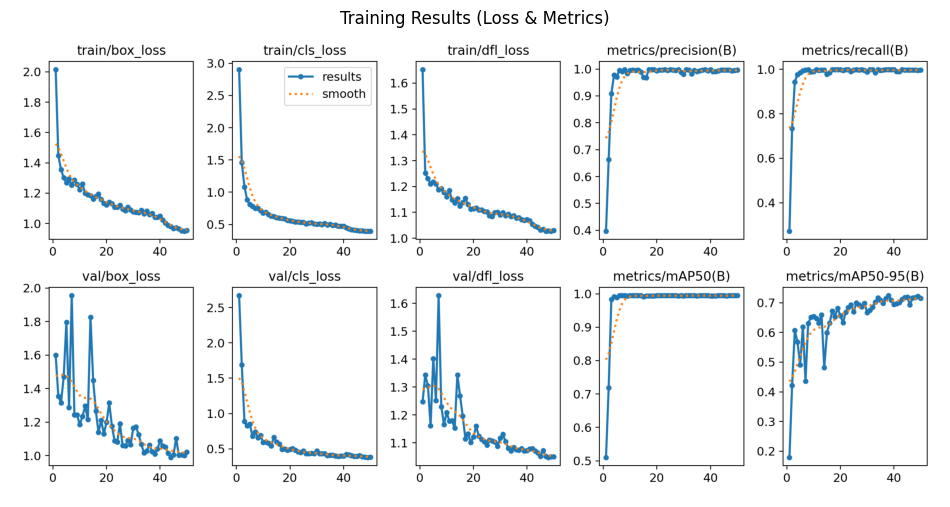

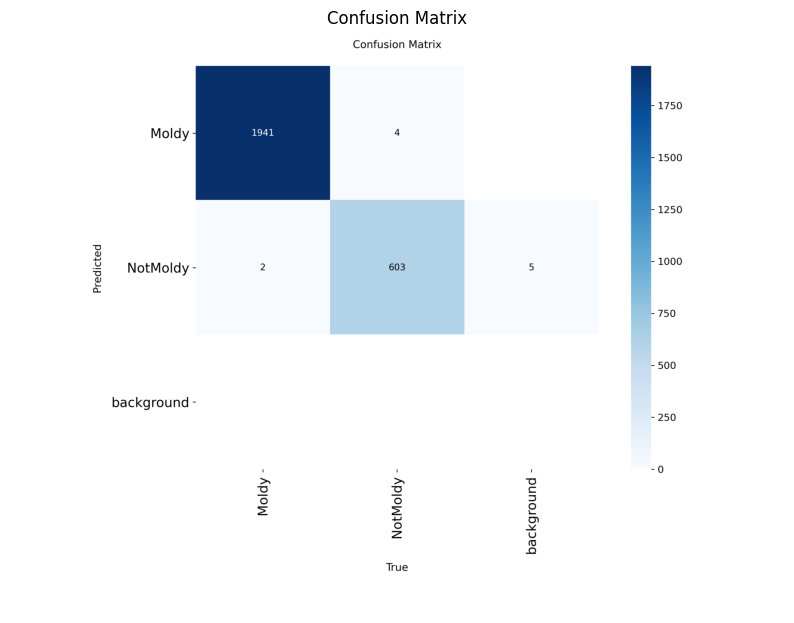

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Path ke hasil pelatihan terbaru (train-2)
latest_train_path = '/content/runs/detect/train-2'

# 1. Menampilkan Results Plot
results_plot = os.path.join(latest_train_path, 'results.png')
if os.path.exists(results_plot):
    plt.figure(figsize=(12, 12))
    img = mpimg.imread(results_plot)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Training Results (Loss & Metrics)')
    plt.show()

# 2. Menampilkan Confusion Matrix
cm_plot = os.path.join(latest_train_path, 'confusion_matrix.png')
if os.path.exists(cm_plot):
    plt.figure(figsize=(10, 10))
    img = mpimg.imread(cm_plot)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Confusion Matrix')
    plt.show()
else:
    print('Grafik hasil tidak ditemukan di direktori train-2.')

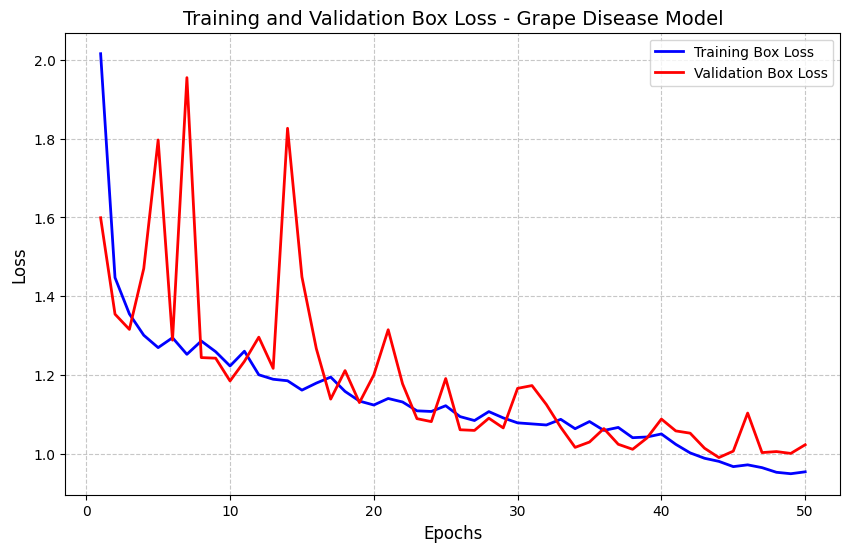

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Path ke file hasil training
results_csv = '/content/Peanut_Model_v1/results.csv'

if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    plt.figure(figsize=(10, 6))

    # Plot Training Loss
    plt.plot(df['epoch'], df['train/box_loss'], label='Training Box Loss', color='blue', linewidth=2)

    # Plot Validation Loss
    plt.plot(df['epoch'], df['val/box_loss'], label='Validation Box Loss', color='red', linewidth=2)

    plt.title('Training and Validation Box Loss - Grape Disease Model', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print("File results.csv tidak ditemukan. Pastikan training sudah selesai.")

In [ ]:
# 1. Run inference on the Test Set
model_best = YOLO('/content/runs/detect/train-2/weights/best.pt')
test_results = model_best.predict(source='/content/peanut_dataset/test/images', conf=0.5, save=True)

print(f"Test inference complete. Results saved to: {test_results[0].save_dir}")


image 1/86 /content/peanut_dataset/test/images/IMG_20240307_091100_1_jpg.rf.ZgZFThhulWFrkAzkLjmP.jpg: 480x640 23 Moldys, 7 NotMoldys, 62.6ms
image 2/86 /content/peanut_dataset/test/images/IMG_20240307_091100_jpg.rf.1wETgXXQMLldJHSfIzHD.jpg: 480x640 23 Moldys, 7 NotMoldys, 8.4ms
image 3/86 /content/peanut_dataset/test/images/IMG_20240307_091103_1_jpg.rf.JlepJeZqfnLLpymMjFbs.jpg: 480x640 23 Moldys, 7 NotMoldys, 20.7ms
image 4/86 /content/peanut_dataset/test/images/IMG_20240307_091104_2_jpg.rf.hsDPAIJwPy46gFZZpeP6.jpg: 480x640 23 Moldys, 7 NotMoldys, 10.0ms
image 5/86 /content/peanut_dataset/test/images/IMG_20240307_091153_jpg.rf.lycpzC60fvnAidXUp2Aa.jpg: 480x640 21 Moldys, 9 NotMoldys, 11.8ms
image 6/86 /content/peanut_dataset/test/images/IMG_20240307_091158_jpg.rf.HG7r1hgNap8Lr8xhTI8w.jpg: 480x640 21 Moldys, 9 NotMoldys, 46.4ms
image 7/86 /content/peanut_dataset/test/images/IMG_20240307_091158_jpg.rf.RXnG1752g0FIGPYJFL7v.jpg: 480x640 21 Moldys, 9 NotMoldys, 6.7ms
image 8/86 /content/pe

Saving IMG_20240312_133602.jpg to IMG_20240312_133602.jpg

image 1/1 /content/IMG_20240312_133602.jpg: 480x640 24 Moldys, 6 NotMoldys, 715.8ms
Speed: 18.1ms preprocess, 715.8ms inference, 44.2ms postprocess per image at shape (1, 3, 480, 640)


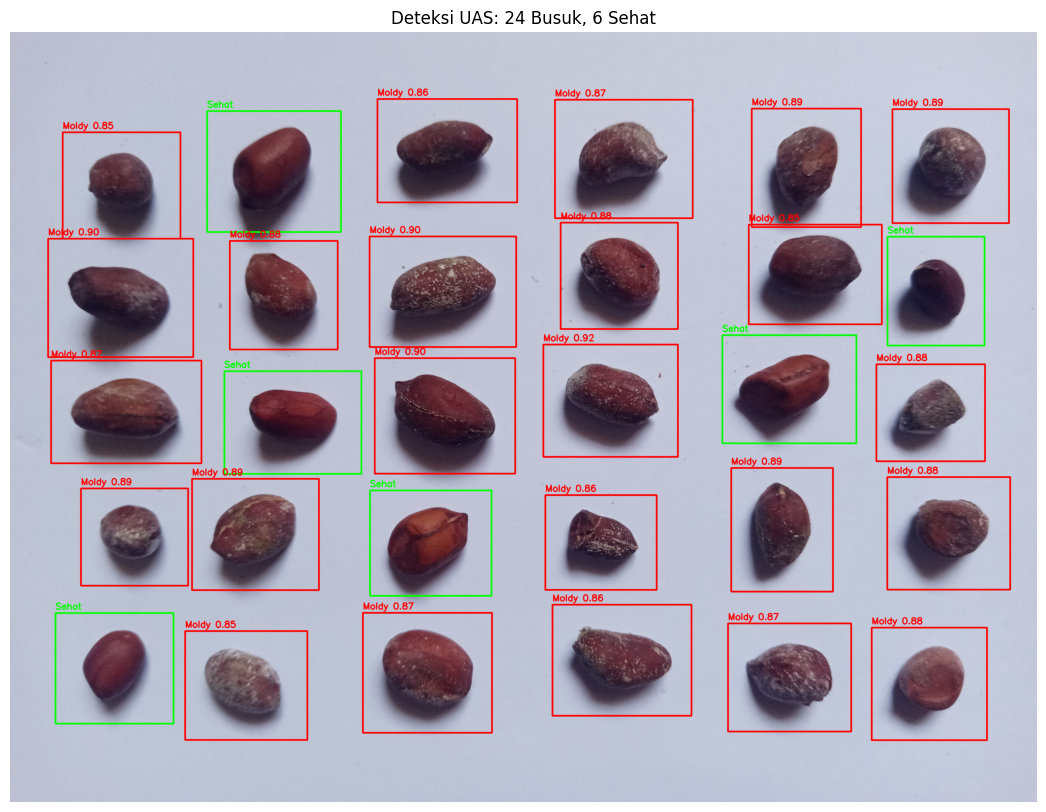


--- HASIL ANALISIS IMG_20240312_133602.jpg ---
Kacang Busuk (Moldy) : 24
Kacang Sehat (Healthy): 6
----------------------------------


In [ ]:
from google.colab import files
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO

# 1. Load model
new_model_path = '/content/Peanut_Model_v1/weights/best.pt'
current_model = YOLO(new_model_path)

# 2. Upload File
uploaded = files.upload()

for filename in uploaded.keys():
    # 3. Jalankan Prediksi
    results = current_model.predict(source=filename, conf=0.80, augment=True, save=False)
    res = results[0]
    img_bgr = cv2.imread(filename)

    count_moldy = 0
    count_healthy = 0

    # 4. Gambar manual untuk kontrol ketebalan dan warna
    for box in res.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        cls = int(box.cls[0])
        label_name = res.names[cls]

        if label_name == 'Moldy':
            color = (0, 0, 255) # Merah (BGR)
            count_moldy += 1
            label_text = f"Moldy {conf:.2f}"
            # Box lebih tebal (thickness=6)
            cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color, 6)
            # Label lebih besar (scale=1.2, thickness=3)
            cv2.putText(img_bgr, label_text, (x1, y1 - 15), cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)
        else:
            color = (0, 255, 0) # Hijau (BGR)
            count_healthy += 1
            label_text = "Sehat"
            # Box lebih tebal (thickness=6)
            cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color, 6)
            # Label tanpa angka keyakinan, ukuran besar
            cv2.putText(img_bgr, label_text, (x1, y1 - 15), cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)

    # 5. Tampilkan Hasil
    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Deteksi UAS: {count_moldy} Busuk, {count_healthy} Sehat")
    plt.show()

    print(f"\n--- HASIL ANALISIS {filename} ---")
    print(f"Kacang Busuk (Moldy) : {count_moldy}")
    print(f"Kacang Sehat (Healthy): {count_healthy}")
    print("----------------------------------")

In [ ]:
from google.colab import drive
import shutil
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Tentukan path asal dan tujuan
source_dir = '/content/runs/detect/train-2'
destination_dir = '/content/drive/MyDrive/Peanut_Model_v1'

# 3. Salin folder
try:
    if os.path.exists(source_dir):
        shutil.copytree(source_dir, destination_dir, dirs_exist_ok=True)
        print(f'✅ Berhasil! Folder {source_dir} telah disimpan ke Drive sebagai: {destination_dir}')
    else:
        print(f'❌ Error: Folder sumber {source_dir} tidak ditemukan.')
except Exception as e:
    print(f'❌ Terjadi kesalahan saat menyalin: {e}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Berhasil! Folder /content/runs/detect/train-2 telah disimpan ke Drive sebagai: /content/drive/MyDrive/Peanut_Model_v1
